dtype('uint8')

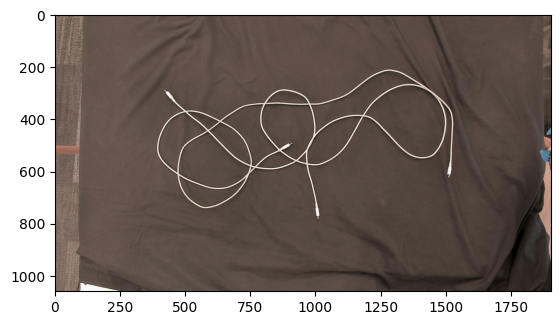

In [36]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch

im_frame2 = Image.open("/home/justinyu/vsumedh/data/raw_images/parallel-20240730-152135.png")

np_frame2 = np.array(im_frame2)
plt.imshow(np_frame2)

np_frame2.dtype

In [37]:
print(np_frame2.shape)
np_frame2 = np_frame2[:, 0:1800,:]

(1060, 1904, 3)


(1060, 1800, 3)
Endpoint detection took 0.6124932765960693 seconds


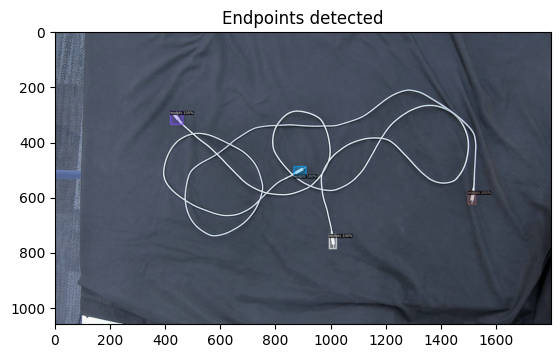

(1060, 1800, 3)
[[ 761 1006]
 [ 603 1510]
 [ 313  440]
 [ 505  886]]


<Figure size 640x480 with 0 Axes>

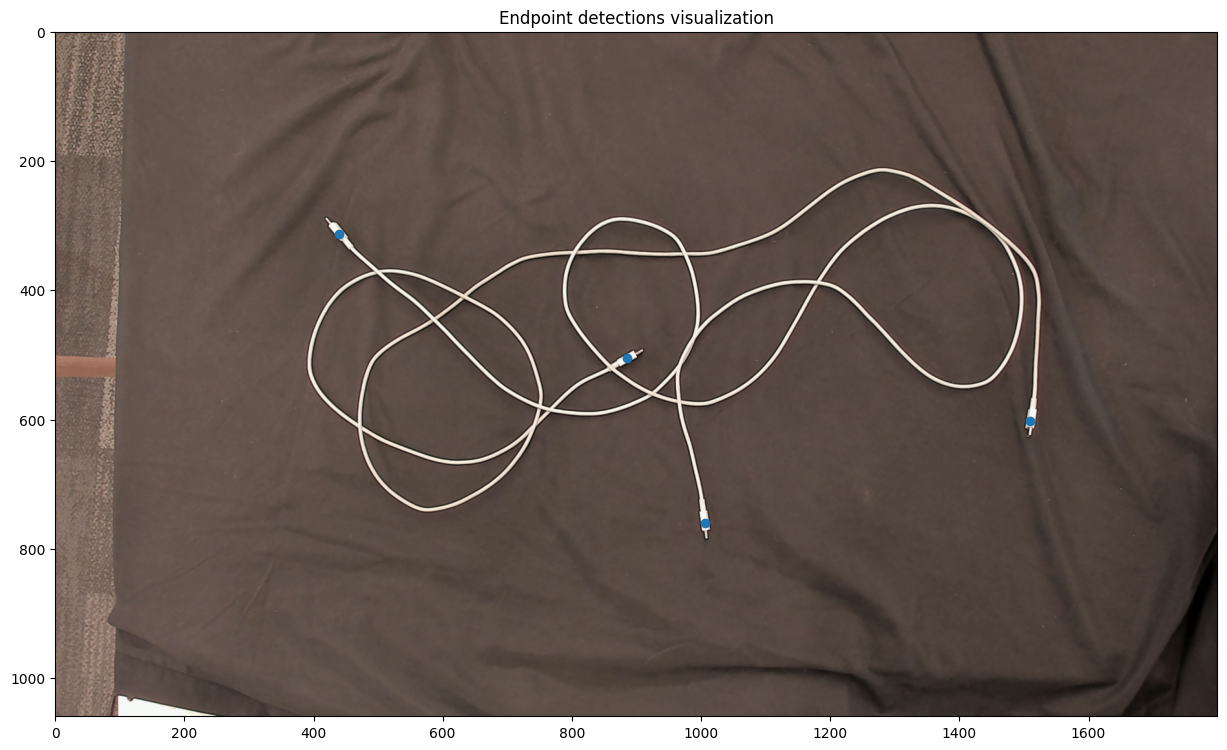

In [38]:
img = np_frame2
from decluttering.data.detectron2_repo import analysis as loop_detectron
import numpy as np 
import time

def get_endpoints(img):
    endpoint_start = time.time()
    endpoint_boxes, out_viz = loop_detectron.predict(img, thresh=0.99, endpoints=True)
    endpoint_end = time.time()
    print("Endpoint detection took {} seconds".format(endpoint_end - endpoint_start))
    plt.clf()
    plt.imshow(out_viz)
    plt.title("Endpoints detected")
    plt.show()
    plt.imsave("/home/justinyu/multicable-decluttering/misc_images/endpoints_detected.png", out_viz)
    print(out_viz.shape)

    endpoints = []
    for i, box in enumerate(endpoint_boxes):
        xmin, ymin, xmax, ymax = box
        x = (xmin + xmax)/2
        y = (ymin + ymax)/2
        endpoints.append([y, x])   
    endpoints = np.array(endpoints).astype(np.int32)
    print(endpoints)

    plt.clf()
    plt.figure(figsize=(15,18))
    plt.title("Endpoint detections visualization")
    plt.imshow(img)
    if len(endpoints) > 0:
        plt.scatter(endpoints[:, 1], endpoints[:, 0])
    plt.show()
    return endpoints

print(img.shape)
endpts = get_endpoints(img)

Loading pretrained CLIP
Resetting zs_weight datasets/metadata/lvis_v1_clip_a+cname.npy
Inference time:  0.08170461654663086
Number of masks before filtering torch.Size([2, 1, 1060, 1800])
Area of masks before filtering tensor([ 101830, 1790930], device='cuda:0')
torch.Size([0, 1, 1060, 1800])


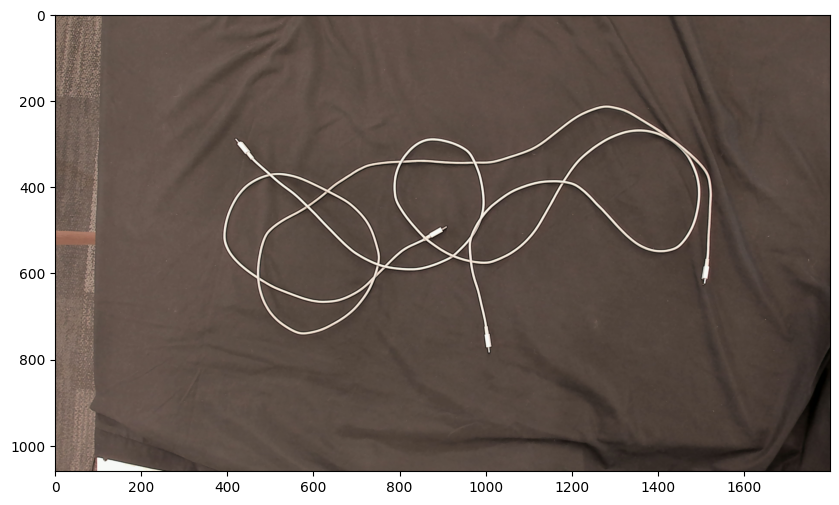

In [39]:
from decluttering.data.utils.detic_dataloader import DeticDataloader

detic = DeticDataloader()
detic.create()
detic.default_vocab()
out = detic.predict(np_frame2)
import torch
num_masks = out['masks'].shape[0]
print("Number of masks before filtering", out['masks'].shape)
print("Area of masks before filtering", torch.sum(out['masks'], dim = (1,2,3)))

def filter_mask_by_area(masks, max_area = 17000, min_area = 500):
    """
    Filter masks by area
    """
    mask_areas = torch.sum(masks, dim = (1,2,3))
    mask_areas = mask_areas.cpu().numpy()
    mask_areas = mask_areas.reshape(-1)
    masks_filtered = masks[(mask_areas < max_area) & (min_area < mask_areas)]
    return masks_filtered

filtered_areas = filter_mask_by_area(out['masks'])
print(filtered_areas.shape)
num_masks = filtered_areas.shape[0]

starting_block = filter_mask_by_area(out['masks'], max_area = 24000, min_area = 17000)
detic.visualize_output(np_frame2, filtered_areas, image_save_path=f"detic_masks/filtered_masks{time}.png")

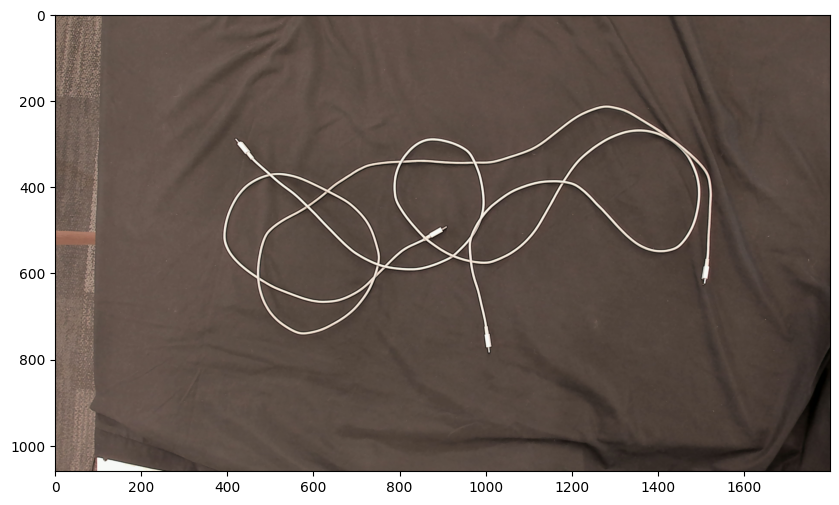

In [40]:
detic.visualize_output(np_frame2, starting_block)

In [41]:
from decluttering.data.tracer.analytic_tracer.simple_uncertain_trace_single import trace

def analytic_tracer(img, point, keepout_mask=None):
        # trace from endpoint on image
        path, finished_paths = trace(img, point, exact_path_len=3, viz=False, keepout_mask=keepout_mask)
        agree_point = tuple(np.array([point[0], point[1]]).astype(np.int32))
        if path is None:
            if len(finished_paths) > 0:
                min_len_path = float('inf')
                for fp in finished_paths:
                    if len(fp) < min_len_path:
                        min_len_path = len(fp)
                for i in range(min_len_path):
                    values = np.array([list(fp[i]) for fp in finished_paths])
                    x = values[:, 0]
                    y = values[:, 1]
                    x_diff = np.max(x)-np.min(x)
                    y_diff = np.max(y)-np.min(y)
                    if x_diff < 5 and y_diff < 5:
                        agree_point = values[0]
            return agree_point, True
        return path, False



In [42]:
import colorsys
from collections import OrderedDict

def visualize_trace_solid_color(img, path, black=False, color=None):
    img = img.copy()
    def color_for_pct(pct):
        return colorsys.hsv_to_rgb(pct, 1, 1)[0] * 255, colorsys.hsv_to_rgb(pct, 1, 1)[1] * 255, colorsys.hsv_to_rgb(pct, 1, 1)[2] * 255
    def color_heatmap(pct):
        return colorsys.hsv_to_rgb(pct/3, 1, 1)[0] * 255, colorsys.hsv_to_rgb(pct/3, 1, 1)[1] * 255, colorsys.hsv_to_rgb(pct/3, 1, 1)[2] * 255
    for i in range(len(path) - 1):
        
        # if path is ordered dict, use below logic
        if not isinstance(path, OrderedDict):
            pt1 = tuple(path[i].astype(int))
            pt2 = tuple(path[i+1].astype(int))
        else:
            path_keys = list(path.keys())
            pt1 = path_keys[i]
            pt2 = path_keys[i + 1]
        # print(color_for_pct(i/len(path)))

        cv2.line(img, pt1[::-1], pt2[::-1], color, 2 if not black else 5)
    return img

ON ENDPOINT: [ 761 1006]
Autoregressive Tracer Using GPU
Autoregressive Tracer Using GPU
Beginning trace with 4 start pixels
Elapsed time for tracing: 0.16s


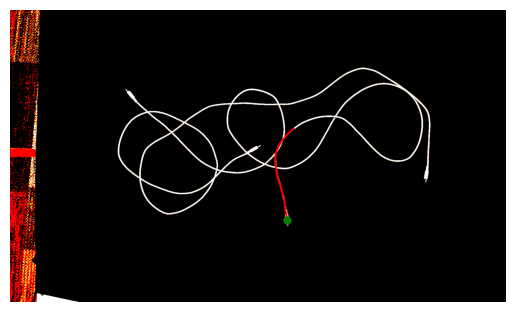

ON ENDPOINT: [ 603 1510]
Autoregressive Tracer Using GPU
Autoregressive Tracer Using GPU
Beginning trace with 4 start pixels
Elapsed time for tracing: 0.15s


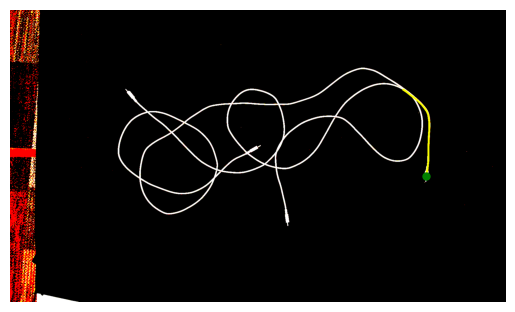

ON ENDPOINT: [313 440]
Autoregressive Tracer Using GPU
Autoregressive Tracer Using GPU
Beginning trace with 4 start pixels
Elapsed time for tracing: 0.14s


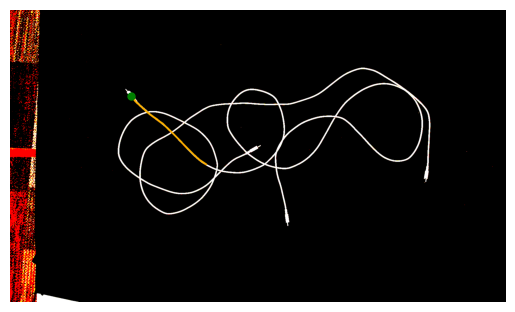

ON ENDPOINT: [505 886]
Autoregressive Tracer Using GPU
Autoregressive Tracer Using GPU
Beginning trace with 4 start pixels
Elapsed time for tracing: 0.14s


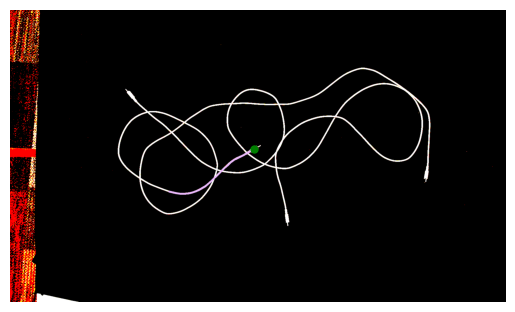

In [ ]:
RED_COLOR = (255, 0, 0)
YELLOW_COLOR = (255, 255, 0)
MAGENTA_COLOR = (235, 52, 177)
ORANGE_COLOR = (255, 178, 0)
LILAC_COLOR = (235, 185, 252)
YELLOW_COLOR = (252, 255, 0)
TURQUOISE_COLOR = (0, 255, 188)
RED_COLOR = (255, 0, 0)
LIME_COLOR = (205, 255, 135)

colors = [RED_COLOR, MAGENTA_COLOR, ORANGE_COLOR, LILAC_COLOR, YELLOW_COLOR, TURQUOISE_COLOR, RED_COLOR, LIME_COLOR]
img_mask_list = []
for random_endpt in range(len(endpts)):

    print("ON ENDPOINT: " + str(np.array(endpts[random_endpt])))

    starting_pixels = analytic_tracer(img, np.array(endpts[random_endpt]), keepout_mask=None)

    # print("FIRST STARTING PIXEL: " + str(np.asarray(starting_pixels[0]).astype(int)))
    # print(f"X COORD FOR ENDPOINT = {endpts[random_endpt][0]}")
    # print(f"Y COORD FOR ENDPOINT = {endpts[random_endpt][1]}")


    # TRACER + HEATMAP
    from decluttering.data.tracer.tusk_pipeline.tracer import Tracer
    import datetime
    from decluttering.data.utils.tracer_dataloader import TracerDataloader
    time = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S")
    tracer = TracerDataloader()

    out = tracer.predict(img, np.asarray(starting_pixels[0]).astype(int), endpoints=endpts)
    trace_path = out["trace"]
    heatmaps = out["heatmaps"]
    plt.clf()

    # plt.imshow(tracer.tracer.visualize_path(img, np.array(trace_path)))
    plt.axis('off')
    # plt.imsave(f"/home/justinyu/multicable-decluttering/decluttering/scripts/test/cable_uncertainty/path_certainty_{time}_trace.png", tracer.tracer.visualize_path(img, np.array(trace)))

    # Veena: heatmap for ViT

    vit_conf_path = out["vit"]
    # print("VIT HEATMAP FOR ENDPOINT: " + str(random_endpt))
    tracer_viz_path = tracer.tracer.visualize_path(img, np.array(trace_path), color=vit_conf_path)
    # plt.imshow(tracer_viz_path)
    # plt.axis('off')
    # plt.show()

    ############# APPLYING IMAGE THRESHOLD TO MAKE BLACK AND WHITE MASK ####### 
    import cv2

    _, img_thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    # plt.imshow(img_thresh)
    # plt.show()

    img_thresh_with_path = visualize_trace_solid_color(img_thresh, trace_path, color = colors[random_endpt], black = True)
    plt.imshow(img_thresh_with_path)
    plt.plot(endpts[random_endpt][1], endpts[random_endpt][0], "og", markersize=5)
    plt.show()

    all_black_img = np.zeros(img.shape, dtype=np.uint8)
    img_mask_only = visualize_trace_solid_color(all_black_img, trace_path, color = colors[random_endpt], black = True)
    img_mask_list.append(img_mask_only)
    # plt.imshow(img_mask_only)
    # plt.imsave(f"/home/justinyu/multicable-decluttering/decluttering/scripts/test/cable_uncertainty/img_mask_{time}_trace.png", img_mask_only)
    # plt.show()
    # plt.imsave(f"/home/justinyu/multicable-decluttering/decluttering/scripts/test/cable_uncertainty/path_certainty_{time}_vit.png", tracer.tracer.visualize_path(img, np.array(trace), color=vit_conf_path))

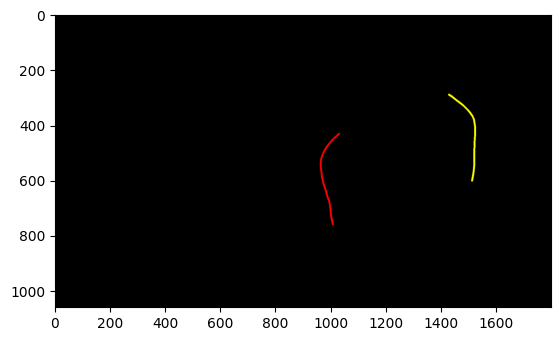

In [44]:
# adding blue and lilac masks together
blue_magenta = img_mask_list[0] + img_mask_list[1]
plt.imshow(blue_magenta)
plt.show()

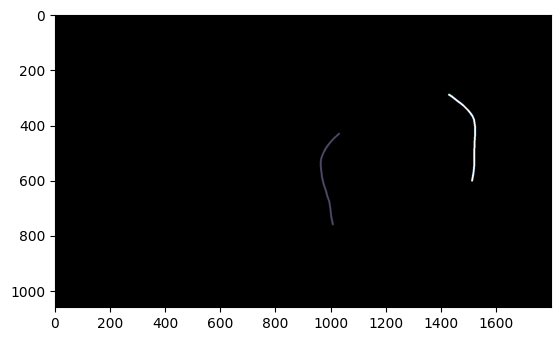

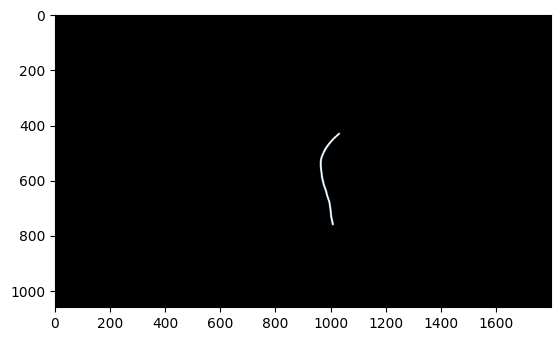

In [45]:
from matplotlib import cm

grayscale = cv2.cvtColor(blue_magenta, cv2.COLOR_RGB2GRAY)
plt.imshow(grayscale, cmap=cm.bone)
plt.show()

# TODO: 100 is hardcoded
_, layered_thresh = cv2.threshold(grayscale, 100, 255, cv2.THRESH_TOZERO_INV)
# layered_thresh = cv2.bitwise_not(layered_thresh)
plt.imshow(layered_thresh, cmap=cm.bone)
plt.show()

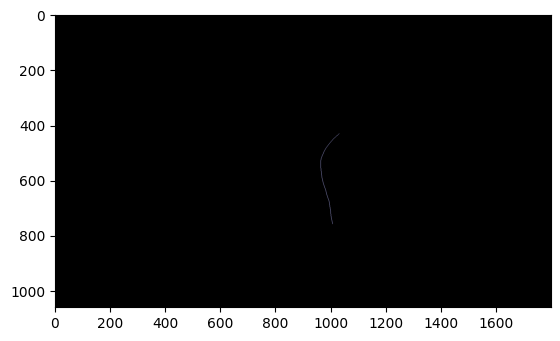

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [46]:
from skimage.morphology import skeletonize
# print(np.nonzero(layered_thresh))
skel_img = skeletonize(layered_thresh, method = "lee")
plt.imshow(skel_img, cmap=cm.bone)
plt.show()

# convert to binary
bin_img = skel_img // 28
bin_img[np.nonzero(bin_img)]

np.min(neighbor_sum) = 0
np.max(neighbor_sum) = 6
np.min(middle_ones_neighbor_sum) = 0
np.max(middle_ones_neighbor_sum) = 12
points_of_interest = array([], shape=(0, 2), dtype=int64)


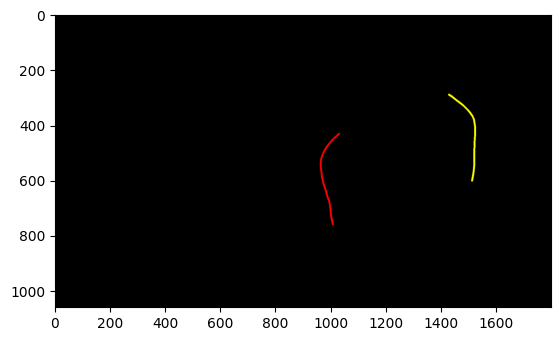

In [47]:
from scipy.ndimage import convolve
kernel = np.array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]])

neighbor_sum = convolve(bin_img, kernel, mode='constant')
print(f"{np.min(neighbor_sum) = }")
print(f"{np.max(neighbor_sum) = }")


middle_ones_neighbor_sum = np.multiply(neighbor_sum, bin_img) # if 1 in center of 3x3, sums up all neighbors including center pixel, for each pixel on image
print(f"{np.min(middle_ones_neighbor_sum) = }")
print(f"{np.max(middle_ones_neighbor_sum) = }")

# visualize middle_ones_neighbor_sum
# bright_img = middle_ones_neighbor_sum * 70
plt.imshow(blue_magenta, cmap=cm.bone)
# plt.show()

# neighbor_sum[np.nonzero(bin_img)].shape

points_of_interest = np.flip(np.argwhere(middle_ones_neighbor_sum == 2), axis = 1)
print(f"{points_of_interest = }")
# print(points_of_interest.T)
# print(np.nonzero(middle_ones_neighbor_sum == 2))

plt.scatter(points_of_interest.T[0], points_of_interest.T[1])
plt.show()

[]


IndexError: index 0 is out of bounds for axis 0 with size 0

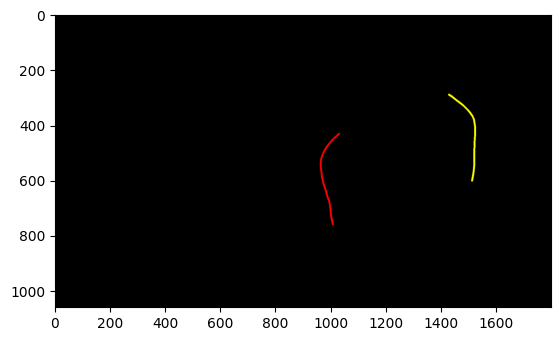

In [48]:
import math
divergence_pts = np.empty([0, 0])

# print(endpts)
for poi in points_of_interest:
    close_to_endpt = False
    for glob_endpt in np.flip(endpts, axis = 1):
        # print(f"{poi = }, {glob_endpt = }, dist = {np.linalg.norm(glob_endpt - poi)}")
        if np.linalg.norm(glob_endpt - poi) <= 20:
            close_to_endpt = True
    if not close_to_endpt:
        divergence_pts = np.append(divergence_pts, poi)

print(divergence_pts)
plt.imshow(blue_magenta)
plt.scatter(divergence_pts.T[0], divergence_pts.T[1])
plt.show()